In [1]:
from IPython.display import display
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

rng = np.random.default_rng()

In [2]:
# Use styling that is consistent with empirical analysis
entropy_colors = {
    'Shannon': 'black',
    'Norm Shannon': 'black',
    'Tsallis': 'black',
}
entropy_lines = {
    'Shannon': '-',
    'Norm Shannon': ':',
    'Tsallis': '-.',
}
entropy_labels = {
    'Shannon': 'Shannon',
    'Norm Shannon': 'Normalized',
    'Tsallis': 'Tsallis',
}
# Use consistent domain size/range with plots
DOMAIN_MAX = 10000 # 10k
N = DOMAIN_MAX
domain_sizes = list(range(1, DOMAIN_MAX + 1))


In [3]:
from scipy.stats import entropy
# shannon entropy (standard measurement)

def get_shannon_entropy(pk):
  assert(pk.sum().round(10) == 1)
  return entropy(pk, base=2) # unit is bits

def get_normalized_shannon_entropy(pk, N):
  assert(pk.sum().round(10) == 1)
  return get_shannon_entropy(pk)/math.log(N, 2)

def get_tsallis_entropy(pk):
  assert(pk.sum().round(10) == 1)
  return 1 - pk.pow(2).sum()

## Example 1

|X|=10, H(X)=3.32


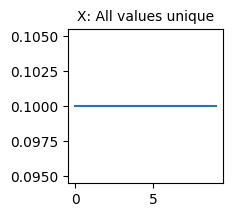

In [4]:
def get_pX_all_unique(D):
  return pd.Series([1/D]*D)

D = 10
pX = get_pX_all_unique(D)
print('|X|=%s, H(X)=%0.2f' % (D, get_shannon_entropy(pX)))
fig, ax = plt.subplots(1,1, figsize=(2,2))
ax.set_title('X: All values unique', fontdict={'fontsize':10})
_ = ax.plot(pX)

X follows power law distribution
sum(X)=1.000
|X|=10000, H(X)=9.53


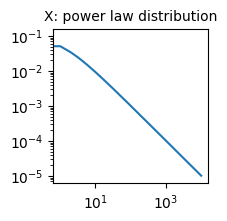

In [5]:
def get_pX_power_law_dist(domain_size):
  """f(x)=x^(-1)"""
  X = np.array([1 / (d + 1) for d in range(domain_size)])
  X = X / sum(X)
  return pd.Series(X)

# D = 100
# D = 1000
D = DOMAIN_MAX
pX = get_pX_power_law_dist(D)
print('X follows power law distribution')
print('sum(X)=%0.3f' % sum(pX))
print('|X|=%s, H(X)=%0.2f' % (D, get_shannon_entropy(pX)))
fig, ax = plt.subplots(1,1, figsize=(2,2))
ax.set_title('X: power law distribution', fontdict={'fontsize':10})
_ = ax.plot(pX)
_ = ax.set_xscale('log')
_ = ax.set_yscale('log')

In [6]:
""""
1.A
Samples of increasing size, ranging from n=1 to 10,000, are drawn from a population
distributed by the power law, f(x)=x-1, where the true domain size is 10,000.
For each sample, we take the observed domain size and entropy estimated for the sample, averaged over 100 trials

"""
ns = [int(n) for n in np.logspace(1, 4, 100)]
D = DOMAIN_MAX #= 10000 # 10k
trials = 100
print('domain size %s; T=%s trials' % (D, trials))

pX = get_pX_power_law_dist(D)
avg_observed_domains = []
avg_shannon_entropy_values = []
avg_norm_shannon_entropy_values = []
avg_tsallis_entropy_values = []
for n in ns:
  if n%1000 == 0:
    print(n)
  observed_domain = 0
  H_hat = 0
  NormH_hat = 0
  T_hat = 0
  for t in range(trials):
    # Draw samples from distribution
    samples = rng.choice(D, size=n, p=pX)
    observed_domain += len(set(samples))
    # Estimate entropies from samples
    _, counts = np.unique(samples, return_counts=True)
    p_hat = pd.Series(counts / sum(counts))
    H_hat += get_shannon_entropy(p_hat)
    NormH_hat += get_normalized_shannon_entropy(p_hat, N=n)
    T_hat += get_tsallis_entropy(p_hat)
  # Take the average
  avg_observed_domains += [observed_domain/trials]
  avg_shannon_entropy_values += [H_hat/trials]
  avg_norm_shannon_entropy_values += [NormH_hat/trials]
  avg_tsallis_entropy_values += [T_hat/trials]

data_1A_v1 = pd.DataFrame({
    'n': ns,
    'domain': avg_observed_domains,
    'Shannon': avg_shannon_entropy_values,
    'Norm Shannon': avg_norm_shannon_entropy_values,
    'Tsallis': avg_tsallis_entropy_values,
}).set_index('n')
data_1A_v1.head()

domain size 10000; T=100 trials
1000
10000


,domain,Shannon,Norm Shannon,Tsallis
n,,,,
10,9.33,3.175889,0.956038,0.883200
10,9.35,3.184379,0.958594,0.885000
11,10.24,3.309619,0.956694,0.893554
12,11.19,3.441597,0.960009,0.903472
13,11.90,3.512955,0.949335,0.905680


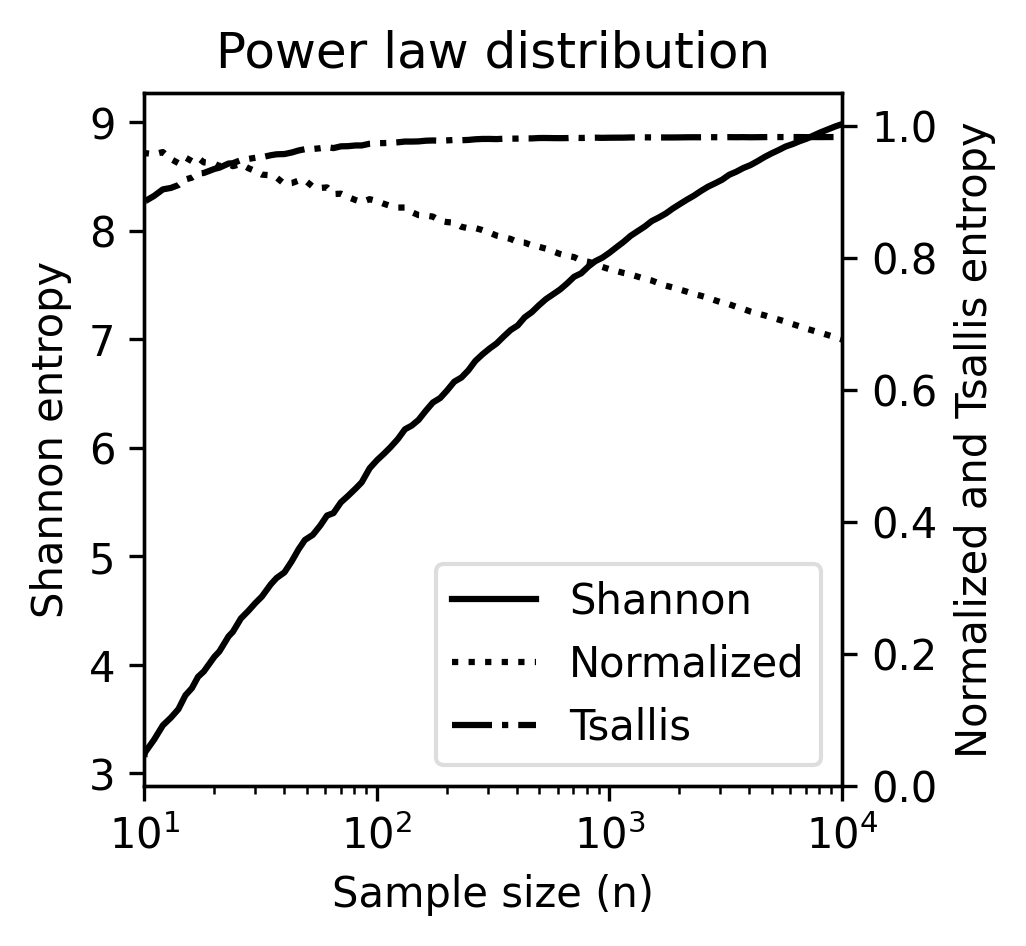

In [7]:
data = data_1A_v1
fig, ax = plt.subplots(1,1, figsize=(3,3), dpi=300)
ax.set_title('Power law distribution')
lns = ax.plot(data.index, data['Shannon'], entropy_lines['Shannon'], label=entropy_labels['Shannon'], color=entropy_colors['Shannon'])
ax.set_ylabel('Shannon entropy')
#ax.set_yticks([3,5,7,9])
ax2 = ax.twinx()
ax2.set_ylim(0, 1.05)
ax2.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
lns += ax2.plot(data.index, data['Norm Shannon'], entropy_lines['Norm Shannon'], label=entropy_labels['Norm Shannon'], color=entropy_colors['Norm Shannon'])
ax2.set_ylabel('Normalized and Tsallis entropy')
lns += ax2.plot(data.index, data['Tsallis'], entropy_lines['Tsallis'], label=entropy_labels['Tsallis'], color=entropy_colors['Tsallis'])
ax.set_xscale('log')
ax.set_xticks([10,100,1000,10000])
ax.set_xlim(10, 10000)
ax.set_xlabel('Sample size (n)')

labs = [l.get_label() for l in lns]
_ = plt.legend(lns, labs, loc='lower right', facecolor='white', framealpha=0.65)

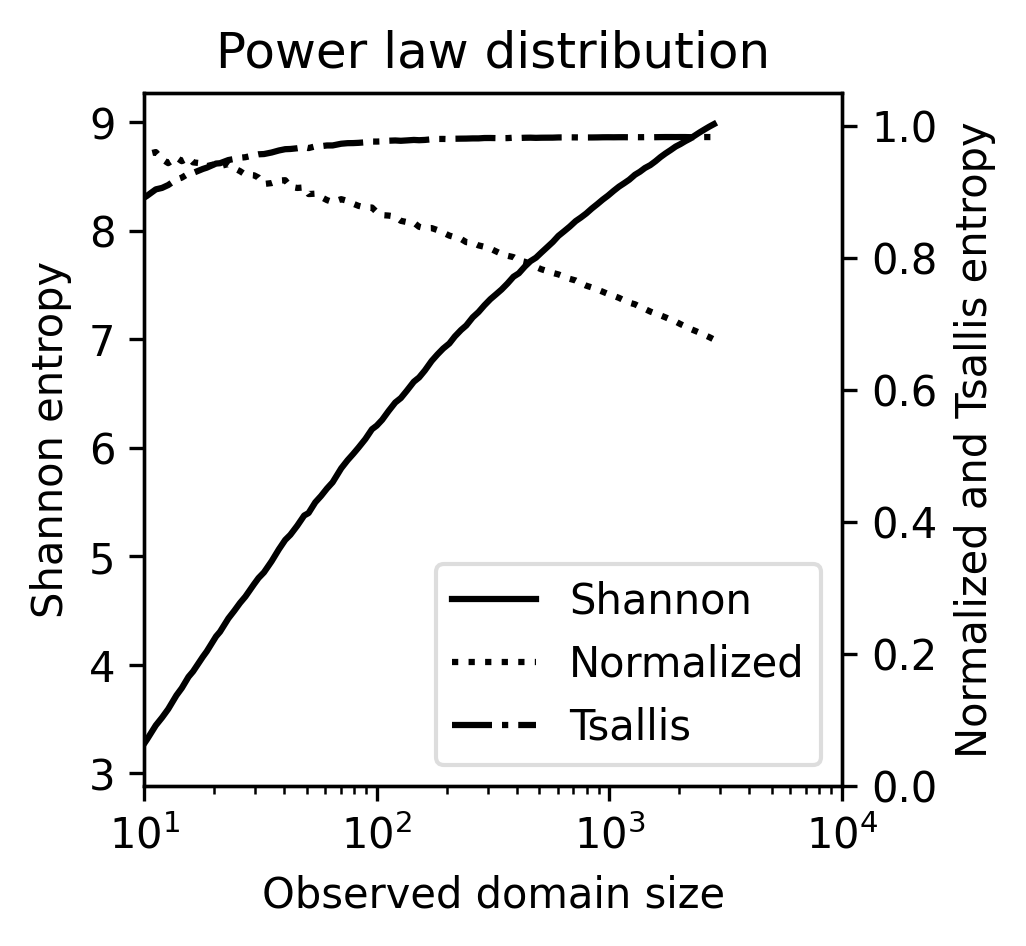

In [8]:
data = data_1A_v1
fig, ax = plt.subplots(1,1, figsize=(3,3), dpi=300)
ax.set_title('Power law distribution')
lns = ax.plot(data['domain'], data['Shannon'], entropy_lines['Shannon'], label=entropy_labels['Shannon'], color=entropy_colors['Shannon'])
ax.set_ylabel('Shannon entropy')
#ax.set_yticks([3,5,7,9])
ax2 = ax.twinx()
ax2.set_ylim(0, 1.05)
ax2.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
lns += ax2.plot(data['domain'], data['Norm Shannon'], entropy_lines['Norm Shannon'], label=entropy_labels['Norm Shannon'], color=entropy_colors['Norm Shannon'])
ax2.set_ylabel('Normalized and Tsallis entropy')
lns += ax2.plot(data['domain'], data['Tsallis'], entropy_lines['Tsallis'], label=entropy_labels['Tsallis'], color=entropy_colors['Tsallis'])
ax.set_xscale('log')
ax.set_xticks([10,100,1000,10000])
ax.set_xlim(10, 10000)
ax.set_xlabel('Observed domain size')

labs = [l.get_label() for l in lns]
_ = plt.legend(lns, labs, loc='lower right', facecolor='white', framealpha=0.65)

In [9]:
"""
1.B.v1
Samples of increasing size, ranging from n=1 to 10,000, are drawn from a population
where all values are unique and the true domain size is 10,000.
For each sample, we plot the observed domain size and entropy estimated for the sample.
"""
N_MAX = 10000
ns = [int(n) for n in np.logspace(1, 4, 100)]
D = DOMAIN_MAX #= 10000 # 10k
print('N max=%s; domain size %s' % (N_MAX, D))

pX = get_pX_all_unique(D)
observed_domains = []
shannon_entropy_values = []
norm_shannon_entropy_values = []
tsallis_entropy_values = []
for n in ns:
  if n%1000 == 0: print(n)
  # Draw samples from distribution
  samples = rng.choice(D, size=n, p=pX, replace=False)
  observed_domains += [len(set(samples))]
  # Estimate entropies from samples
  _, counts = np.unique(samples, return_counts=True)
  p_hat = pd.Series(counts / sum(counts))
  H_hat = get_shannon_entropy(p_hat)
  NormH_hat = get_normalized_shannon_entropy(p_hat, N=n)
  T_hat = get_tsallis_entropy(p_hat)
  shannon_entropy_values += [H_hat]
  norm_shannon_entropy_values += [NormH_hat]
  tsallis_entropy_values += [T_hat]

data_1B_v1 = pd.DataFrame({
    'n': ns,
    'domain': observed_domains,
    'Shannon': shannon_entropy_values,
    'Norm Shannon': norm_shannon_entropy_values,
    'Tsallis': tsallis_entropy_values,
}).set_index('n')
data_1B_v1.head()

N max=10000; domain size 10000
1000
10000


,domain,Shannon,Norm Shannon,Tsallis
n,,,,
10,10,3.321928,1.0,0.900000
10,10,3.321928,1.0,0.900000
11,11,3.459432,1.0,0.909091
12,12,3.584963,1.0,0.916667
13,13,3.700440,1.0,0.923077


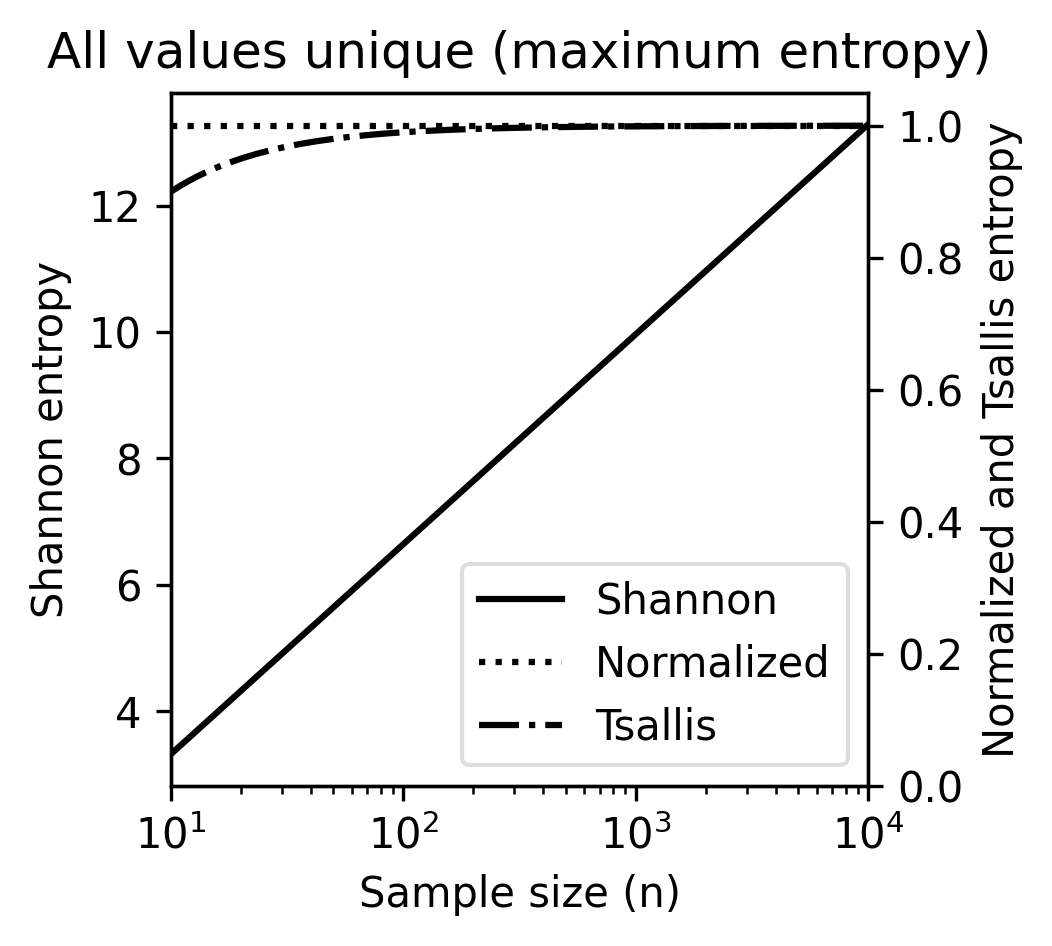

In [10]:
data = data_1B_v1
fig, ax = plt.subplots(1,1, figsize=(3,3), dpi=300)
ax.set_title('All values unique (maximum entropy)')
lns = ax.plot(data.index, data['Shannon'], entropy_lines['Shannon'], label=entropy_labels['Shannon'], color=entropy_colors['Shannon'])
ax.set_ylabel('Shannon entropy')
ax2 = ax.twinx()
ax2.set_ylim(0, 1.05)
ax2.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
lns += ax2.plot(data.index, data['Norm Shannon'], entropy_lines['Norm Shannon'], label=entropy_labels['Norm Shannon'], color=entropy_colors['Norm Shannon'])
ax2.set_ylabel('Normalized and Tsallis entropy')
lns += ax2.plot(data.index, data['Tsallis'], entropy_lines['Tsallis'], label=entropy_labels['Tsallis'], color=entropy_colors['Tsallis'])
ax.set_xscale('log')
ax.set_xticks([10,100,1000,10000])
ax.set_xlim(10, 10000)
ax.set_xlabel('Sample size (n)')

labs = [l.get_label() for l in lns]
_ = plt.legend(lns, labs, loc='lower right', facecolor='white', framealpha=0.65)

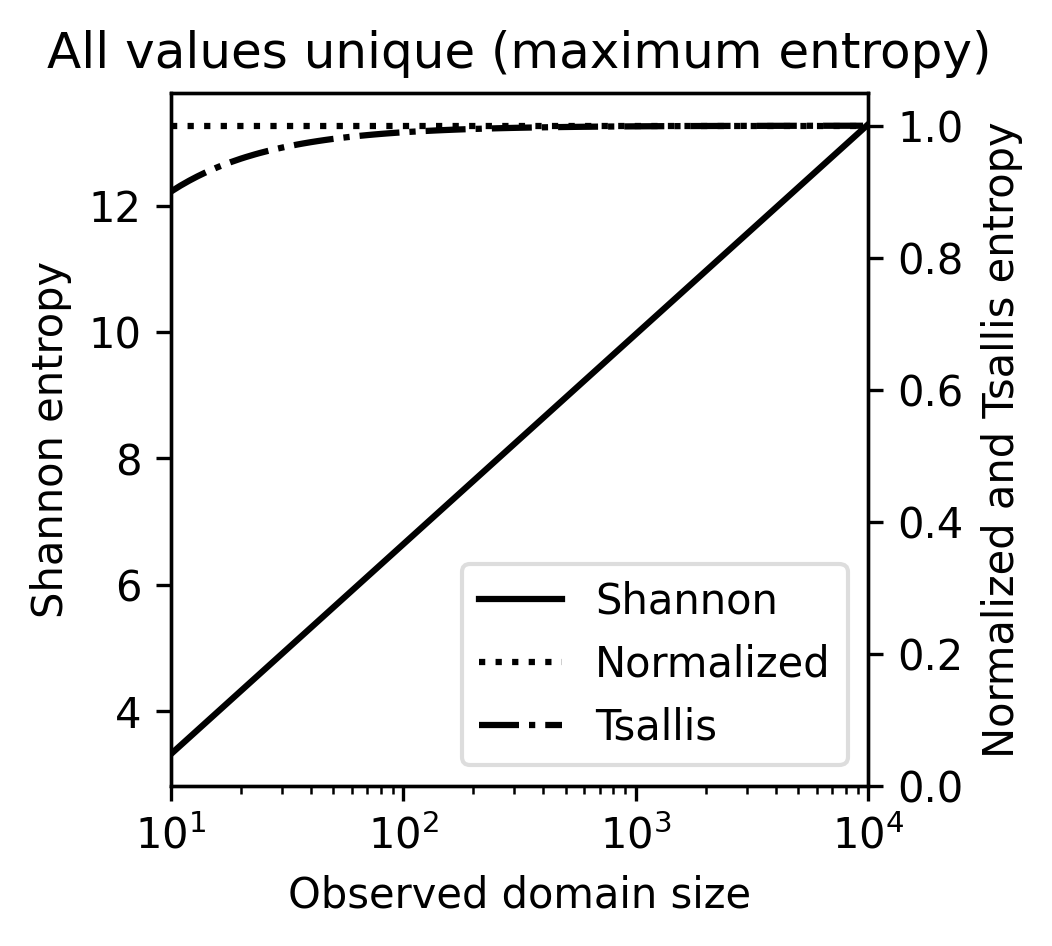

In [11]:
data = data_1B_v1
fig, ax = plt.subplots(1,1, figsize=(3,3), dpi=300)
ax.set_title('All values unique (maximum entropy)')
lns = ax.plot(data['domain'], data['Shannon'], entropy_lines['Shannon'], label=entropy_labels['Shannon'], color=entropy_colors['Shannon'])
ax.set_ylabel('Shannon entropy')
ax2 = ax.twinx()
ax2.set_ylim(0, 1.05)
ax2.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
lns += ax2.plot(data['domain'], data['Norm Shannon'], entropy_lines['Norm Shannon'], label=entropy_labels['Norm Shannon'], color=entropy_colors['Norm Shannon'])
ax2.set_ylabel('Normalized and Tsallis entropy')
lns += ax2.plot(data['domain'], data['Tsallis'], entropy_lines['Tsallis'], label=entropy_labels['Tsallis'], color=entropy_colors['Tsallis'])

ax.set_xscale('log')
ax.set_xticks([10,100,1000,10000])
ax.set_xlim(10, 10000)
ax.set_xlabel('Observed domain size')

labs = [l.get_label() for l in lns]
_ = plt.legend(lns, labs, loc='lower right', facecolor='white', framealpha=0.65)

## Example 2

Normalized entropy is dependent on sample size.

Show: Uniform distribution with domain of size 2

Sample size ranges from 1 to N=10k


p(X)=
0    0.5
1    0.5
dtype: float64
X follows uniform distribution
sum(X)=1.000
|X|=10000, H(X)=1.00


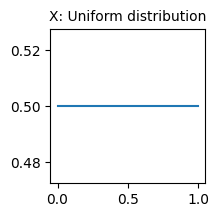

In [12]:
pX = pd.Series([1/2, 1/2])
print('p(X)=')
print(pX)
print('X follows uniform distribution')
print('sum(X)=%0.3f' % sum(pX))
print('|X|=%s, H(X)=%0.2f' % (D, get_shannon_entropy(pX)))
fig, ax = plt.subplots(1,1, figsize=(2,2))
ax.set_title('X: Uniform distribution', fontdict={'fontsize':10})
_ = ax.plot(pX)

In [13]:
print('max N=%s'%N)
sample_sizes = list(range(1, N+1))

shannon_entropy_values = []
norm_shannon_entropy_values = []
tsallis_entropy_values = []
for n in sample_sizes:
  #if n > 10: break
  shannon_entropy_values += [get_shannon_entropy(pX)]
  norm_shannon_entropy_values += [get_normalized_shannon_entropy(pX, N=n)]
  tsallis_entropy_values += [get_tsallis_entropy(pX)]

data_2 = pd.DataFrame({
    'n': sample_sizes,
    'Shannon': shannon_entropy_values,
    'Norm Shannon': norm_shannon_entropy_values,
    'Tsallis': tsallis_entropy_values,
}).set_index('n')
data_2.head()

max N=10000


/tmp/ipython-input-2609770724.py:10: RuntimeWarning: divide by zero encountered in scalar divide
  return get_shannon_entropy(pk)/math.log(N, 2)


,Shannon,Norm Shannon,Tsallis
n,,,
1,1.0,inf,0.5
2,1.0,1.000000,0.5
3,1.0,0.630930,0.5
4,1.0,0.500000,0.5
5,1.0,0.430677,0.5


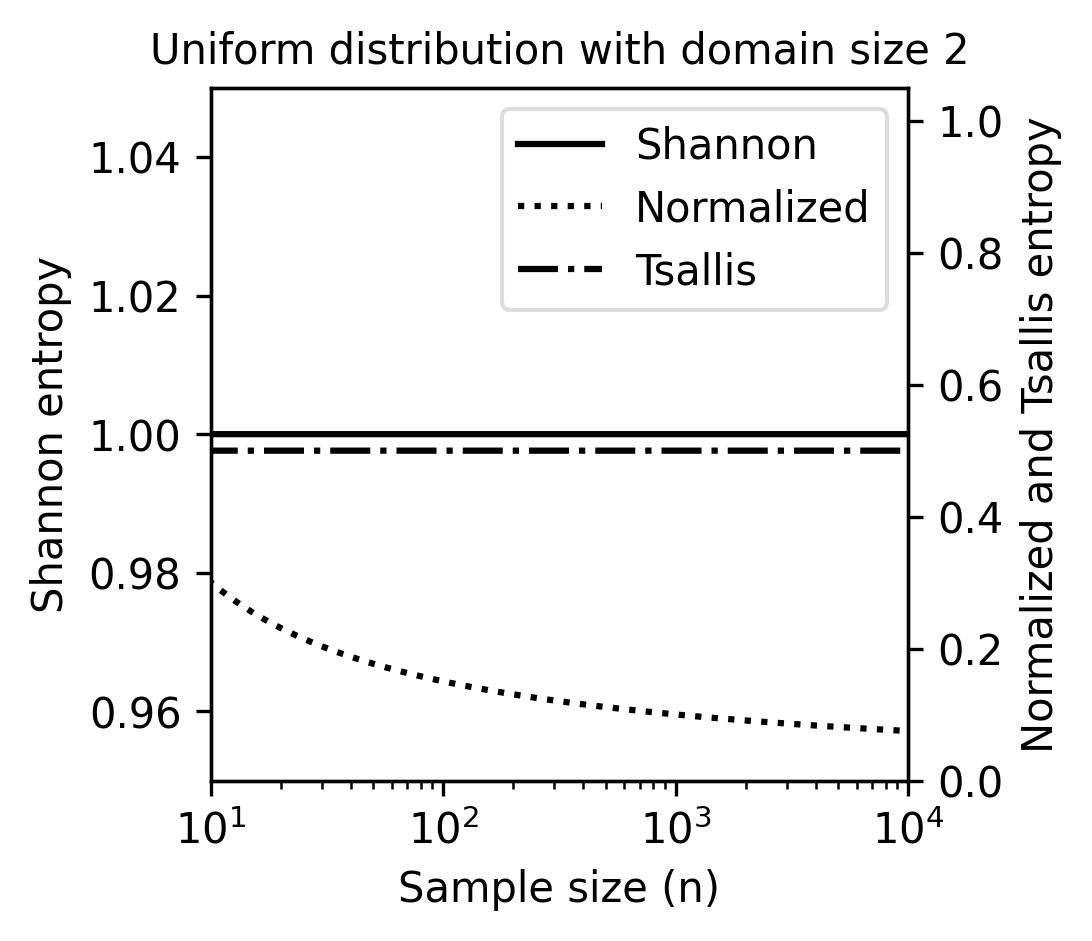

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(3,3), dpi=300)
ax.set_title('Uniform distribution with domain size 2', fontdict={'fontsize':10})
ax.set_xscale('log')
ax.set_xticks([10,100,1000,10000])
ax.set_xlim(10, 10000)
ax.set_xlabel('Sample size (n)')
lns = ax.plot(data_2.index, data_2['Shannon'], entropy_lines['Shannon'], label=entropy_labels['Shannon'], color=entropy_colors['Shannon'])
ax.set_ylabel('Shannon entropy')
ax.set_ylim(0.95, 1.05)
ax.set_yticks([0.96, 0.98, 1.0, 1.02, 1.04])
ax2 = ax.twinx()
ax2.set_ylim(0, 1.05)
ax2.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
lns += ax2.plot(data_2.index, data_2['Norm Shannon'], entropy_lines['Norm Shannon'], label=entropy_labels['Norm Shannon'], color=entropy_colors['Norm Shannon'])
ax2.set_ylabel('Normalized and Tsallis entropy')
lns += ax2.plot(data_2.index, data_2['Tsallis'], entropy_lines['Tsallis'], label=entropy_labels['Tsallis'], color=entropy_colors['Tsallis'])
labs = [l.get_label() for l in lns]
_ = plt.legend(lns, labs, loc='upper right', facecolor='white', framealpha=0.65)

## Example 3

Demonstration of how relative error grows with domain size. Entropy is estimated over the power law distribution, $f(x)=x^{-1}$, where relative error is averaged over T=100 trials.

In [15]:
rng = np.random.default_rng()
N=1000000

def get_entropy_estimates_avg_rel_errors(D, N=N, trials=100, subsample_sizes=None):
  """
  Computes the average relative error for Shannon, Normalized, Tsallis entropies
  computed for the power law distribution, 𝑓(𝑥)=𝑥^{−1}, for domain size D,
  where the sample sizes range from 10 to n.
  Relative errors are averaged over T trials.

  args:
  - D: Domain size
  - N: max sample size
  - trials: number of trials for each subsample size, n

  Returns dataframe where each row corresponds to a subsample of size n.
  Columns:
    n: sumbsample size
    Shannon: shannon avg rel error
    Norm Shannon: norm shannon avg rel error
    Tsallis: tsallis avg rel error
  """
  print('computing average relative errors for power law distrubiton with D=%s, N=%s over T=%s trials' % (D, N, trials))
  # get true values
  pX = get_pX_power_law_dist(D)
  H = get_shannon_entropy(pX)
  NormH = get_normalized_shannon_entropy(pX, N=N)
  T = get_tsallis_entropy(pX)
  # set up avg relative errors lists for each n
  shannon_avg_rel_errors = []
  norm_shannon_avg_rel_errors = []
  tsallis_avg_rel_errors = []
  # Debugging: for Norm entropy
  log_N = math.log(N, 2)
  log_n = [] # math.log(n, 2)
  H_hats = []
  NormH_hats = []
  subsamples = len(subsample_sizes)
  for i, n in enumerate(subsample_sizes):
    if i % 10 == 0:
      print('%s/%s n=%s' % (i, subsamples, n))
    # get estimates
    shannon_cum_rel_error = 0
    norm_shannon_cum_rel_error = 0
    tsallis_cum_rel_error = 0
    # Debugging: Shannon and Norm entropy for debugging
    H_hat_cum = 0
    NormH_hat_cum = 0
    for _t in range(trials):
      # Draw samples from distribution
      samples = rng.choice(D, size=n, p=pX)
      # Estimate entropies from samples
      _, counts = np.unique(samples, return_counts=True)
      p_hat = pd.Series(counts / sum(counts))
      H_hat = get_shannon_entropy(p_hat)
      NormH_hat = get_normalized_shannon_entropy(p_hat, N=n)
      T_hat = get_tsallis_entropy(p_hat)
      # Compute error of estimates
      shannon_cum_rel_error += np.abs(H_hat - H) / H
      norm_shannon_cum_rel_error += np.abs(NormH_hat - NormH) / NormH
      tsallis_cum_rel_error += np.abs(T_hat - T) / T
      # Debugging:
      H_hat_cum += H_hat
      NormH_hat_cum += NormH_hat
    shannon_avg_rel_errors.append(shannon_cum_rel_error / trials)
    norm_shannon_avg_rel_errors.append(norm_shannon_cum_rel_error / trials)
    tsallis_avg_rel_errors.append(tsallis_cum_rel_error / trials)
    # Debugging
    log_n.append(math.log(n, 2))
    H_hats.append(H_hat_cum / trials)
    NormH_hats.append(NormH_hat_cum / trials)
  return pd.DataFrame({
      'n': subsample_sizes,
      'Shannon': shannon_avg_rel_errors,
      'Norm Shannon': norm_shannon_avg_rel_errors,
      'Tsallis': tsallis_avg_rel_errors,
      # included for debugging: log(n), log(N), H(X), H(Xn), H(Xn)/log(n), H(X)/log(N)
      'log(N)': [log_N]*subsamples,
      'H(X)': [H]*subsamples,
      'H(X)/log(N)': [H/log_N]*subsamples,
      'H(Xn)': H_hats,
      'H(Xn)/log(n)': NormH_hats,
      'log(n)':log_n
  }).set_index('n')

In [16]:
# Want ~100 subsamples with size starting at 100 and going to N
steps = 100
step = N/steps
print('step size', int(step))
subsample_sizes = [100] + [int(i*step) for i in range(1, steps + 1)]
assert(subsample_sizes[-1] == N)
data_3_df_dict = dict() # map Domain size, D to the dataframe
Ds = [100, 1000, 10000]
for D in Ds:
  data_3_df_dict[D] = get_entropy_estimates_avg_rel_errors(D=D, N=1000000, trials=100, subsample_sizes=subsample_sizes)
  display(data_3_df_dict[D].head())

step size 10000
computing average relative errors for power law distrubiton with D=100, N=1000000 over T=100 trials
0/101 n=100
10/101 n=100000
20/101 n=200000
30/101 n=300000
40/101 n=400000
50/101 n=500000
60/101 n=600000
70/101 n=700000
80/101 n=800000
90/101 n=900000
100/101 n=1000000


,Shannon,Norm Shannon,Tsallis,log(N),H(X),H(X)/log(N),H(Xn),H(Xn)/log(n),log(n)
n,,,,,,,,,
100,0.122061,1.633818,0.012562,19.931569,5.31024,0.266424,4.662069,0.701711,6.643856
10000,0.003214,0.497677,0.001163,19.931569,5.31024,0.266424,5.302015,0.399016,13.287712
20000,0.002747,0.393779,0.000909,19.931569,5.31024,0.266424,5.305536,0.371336,14.287712
30000,0.001874,0.339685,0.000706,19.931569,5.31024,0.266424,5.308409,0.356924,14.872675
40000,0.001646,0.303212,0.000603,19.931569,5.31024,0.266424,5.307993,0.347207,15.287712


computing average relative errors for power law distrubiton with D=1000, N=1000000 over T=100 trials
0/101 n=100
10/101 n=100000
20/101 n=200000
30/101 n=300000
40/101 n=400000
50/101 n=500000
60/101 n=600000
70/101 n=700000
80/101 n=800000
90/101 n=900000
100/101 n=1000000


,Shannon,Norm Shannon,Tsallis,log(N),H(X),H(X)/log(N),H(Xn),H(Xn)/log(n),log(n)
n,,,,,,,,,
100,0.269768,1.190697,0.011078,19.931569,7.489046,0.375738,5.468743,0.823128,6.643856
10000,0.010356,0.484466,0.000748,19.931569,7.489046,0.375738,7.411491,0.557770,13.287712
20000,0.005061,0.388094,0.000443,19.931569,7.489046,0.375738,7.451891,0.521559,14.287712
30000,0.003776,0.335188,0.000430,19.931569,7.489046,0.375738,7.461337,0.501681,14.872675
40000,0.003034,0.300149,0.000356,19.931569,7.489046,0.375738,7.468281,0.488515,15.287712


computing average relative errors for power law distrubiton with D=10000, N=1000000 over T=100 trials
0/101 n=100
10/101 n=100000
20/101 n=200000
30/101 n=300000
40/101 n=400000
50/101 n=500000
60/101 n=600000
70/101 n=700000
80/101 n=800000
90/101 n=900000
100/101 n=1000000


,Shannon,Norm Shannon,Tsallis,log(N),H(X),H(X)/log(N),H(Xn),H(Xn)/log(n),log(n)
n,,,,,,,,,
100,0.384855,0.845434,0.010337,19.931569,9.532297,0.478251,5.863741,0.882581,6.643856
10000,0.057052,0.414422,0.000546,19.931569,9.532297,0.478251,8.988464,0.676449,13.287712
20000,0.035638,0.345300,0.000421,19.931569,9.532297,0.478251,9.192589,0.643391,14.287712
30000,0.025713,0.305687,0.000309,19.931569,9.532297,0.478251,9.287190,0.624446,14.872675
40000,0.020204,0.277423,0.000246,19.931569,9.532297,0.478251,9.339712,0.610929,15.287712


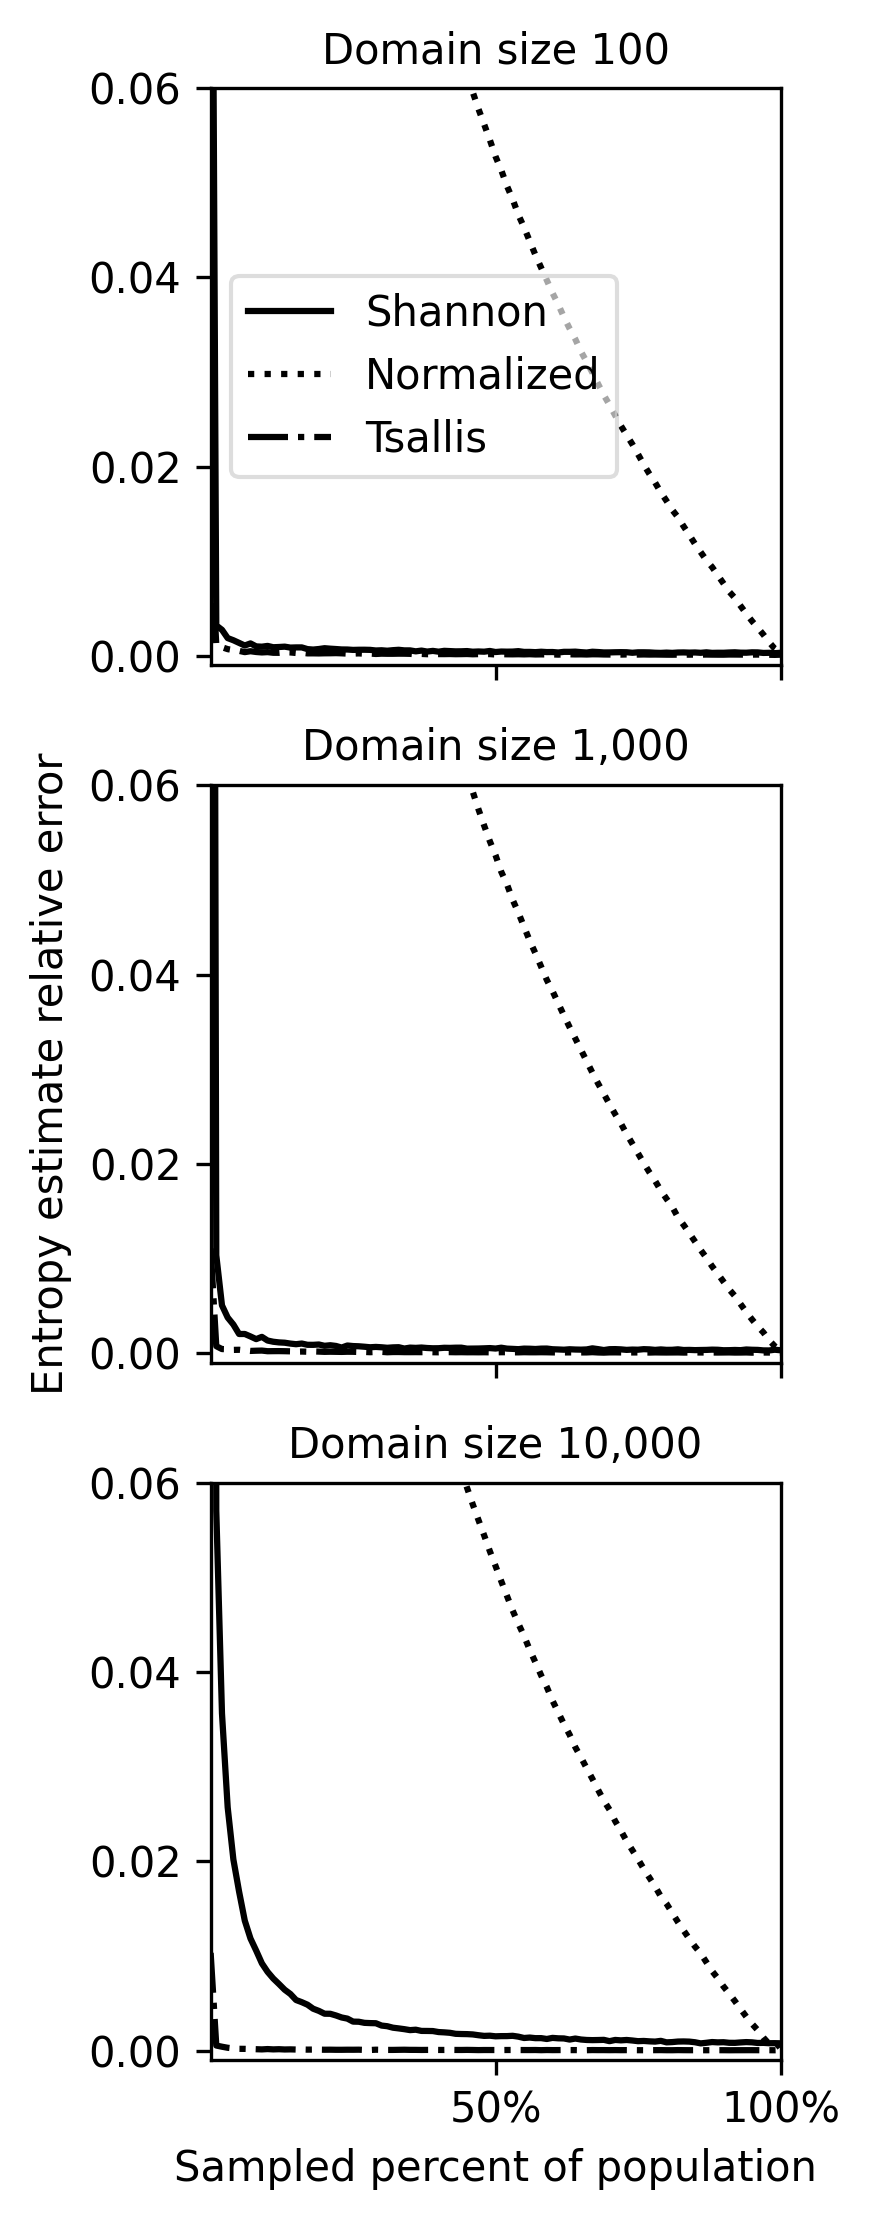

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(3, 7.5), sharey=True, sharex=True, dpi=300)
for i, (D, df) in enumerate(data_3_df_dict.items()):
  ax = axes[i]
  ax.set_title('Domain size %s'%f'{D:,}', fontdict={'fontsize':10})
  if i==1:ax.set_ylabel('Entropy estimate relative error')
  ax.set_xlim(0, N)
  ax.set_ylim(-0.001, 0.06)
  ax.set_yticks([0, 0.02, 0.04, 0.06])
  lns = ax.plot(df.index, df['Shannon'], entropy_lines['Shannon'], label=entropy_labels['Shannon'], color=entropy_colors['Shannon'])
  lns += ax.plot(df.index, df['Norm Shannon'], entropy_lines['Norm Shannon'], label=entropy_labels['Norm Shannon'], color=entropy_colors['Norm Shannon'])
  lns += ax.plot(df.index, df['Tsallis'], entropy_lines['Tsallis'], label=entropy_labels['Tsallis'], color=entropy_colors['Tsallis'])
  if i==0: ax.legend(lns, [l.get_label() for l in lns], loc='center left', facecolor='white', framealpha=0.65)
  if i == 2:
    #ax.set_xlabel('n')
    #ax.set_xticks([N/2, N], ['500,000', '1,000,000'])
    ax.set_xlabel('Sampled percent of population')
    ax.set_xticks([N/2, N], ['50%', '100%'])
plt.tight_layout()

Below shows what would happen if we used even larger domain sizes with same N.
i.e. Domain size 100,000 is only 10x smaller than N. This is a very flat power law distribution.

Note for this quick demonstration, T trials is smaller.

In [18]:
# Want ~100 subsamples with size starting at 100 and going to N
steps = 100
step = N/steps
print('step size', int(step))
subsample_sizes = [100] + [int(i*step) for i in range(1, steps + 1)]
assert(subsample_sizes[-1] == N)
data_3_df_dict2 = dict() # map Domain size, D to the dataframe
Ds = [100, 1000, 10000, 100000]
for D in Ds:
  data_3_df_dict2[D] = get_entropy_estimates_avg_rel_errors(D=D, N=1000000, trials=10, subsample_sizes=subsample_sizes)
  display(data_3_df_dict2[D].head())

step size 10000
computing average relative errors for power law distrubiton with D=100, N=1000000 over T=10 trials
0/101 n=100
10/101 n=100000
20/101 n=200000
30/101 n=300000
40/101 n=400000
50/101 n=500000
60/101 n=600000
70/101 n=700000
80/101 n=800000
90/101 n=900000
100/101 n=1000000


,Shannon,Norm Shannon,Tsallis,log(N),H(X),H(X)/log(N),H(Xn),H(Xn)/log(n),log(n)
n,,,,,,,,,
100,0.139082,1.582753,0.013739,19.931569,5.31024,0.266424,4.571678,0.688106,6.643856
10000,0.002773,0.498845,0.001422,19.931569,5.31024,0.266424,5.306149,0.399328,13.287712
20000,0.002589,0.393661,0.001030,19.931569,5.31024,0.266424,5.305087,0.371304,14.287712
30000,0.001292,0.340743,0.000618,19.931569,5.31024,0.266424,5.312601,0.357205,14.872675
40000,0.001304,0.303511,0.000583,19.931569,5.31024,0.266424,5.309209,0.347286,15.287712


computing average relative errors for power law distrubiton with D=1000, N=1000000 over T=10 trials
0/101 n=100
10/101 n=100000
20/101 n=200000
30/101 n=300000
40/101 n=400000
50/101 n=500000
60/101 n=600000
70/101 n=700000
80/101 n=800000
90/101 n=900000
100/101 n=1000000


,Shannon,Norm Shannon,Tsallis,log(N),H(X),H(X)/log(N),H(Xn),H(Xn)/log(n),log(n)
n,,,,,,,,,
100,0.277770,1.166691,0.014329,19.931569,7.489046,0.375738,5.408815,0.814108,6.643856
10000,0.008462,0.487307,0.000738,19.931569,7.489046,0.375738,7.425672,0.558837,13.287712
20000,0.005235,0.387711,0.000388,19.931569,7.489046,0.375738,7.449838,0.521416,14.287712
30000,0.003995,0.334793,0.000497,19.931569,7.489046,0.375738,7.459129,0.501532,14.872675
40000,0.002458,0.300657,0.000353,19.931569,7.489046,0.375738,7.471198,0.488706,15.287712


computing average relative errors for power law distrubiton with D=10000, N=1000000 over T=10 trials
0/101 n=100
10/101 n=100000
20/101 n=200000
30/101 n=300000
40/101 n=400000
50/101 n=500000
60/101 n=600000
70/101 n=700000
80/101 n=800000
90/101 n=900000
100/101 n=1000000


,Shannon,Norm Shannon,Tsallis,log(N),H(X),H(X)/log(N),H(Xn),H(Xn)/log(n),log(n)
n,,,,,,,,,
100,0.384417,0.846749,0.010490,19.931569,9.532297,0.478251,5.867919,0.883210,6.643856
10000,0.057310,0.414035,0.000585,19.931569,9.532297,0.478251,8.986002,0.676264,13.287712
20000,0.034203,0.347301,0.000369,19.931569,9.532297,0.478251,9.206266,0.644348,14.287712
30000,0.026105,0.305163,0.000271,19.931569,9.532297,0.478251,9.283461,0.624196,14.872675
40000,0.020477,0.277067,0.000249,19.931569,9.532297,0.478251,9.337106,0.610759,15.287712


computing average relative errors for power law distrubiton with D=100000, N=1000000 over T=10 trials
0/101 n=100
10/101 n=100000
20/101 n=200000
30/101 n=300000
40/101 n=400000
50/101 n=500000
60/101 n=600000
70/101 n=700000
80/101 n=800000
90/101 n=900000
100/101 n=1000000


,Shannon,Norm Shannon,Tsallis,log(N),H(X),H(X)/log(N),H(Xn),H(Xn)/log(n),log(n)
n,,,,,,,,,
100,0.471555,0.585335,0.011273,19.931569,11.4954,0.576743,6.074685,0.914331,6.643856
10000,0.132258,0.301613,0.000429,19.931569,11.4954,0.576743,9.975044,0.750697,13.287712
20000,0.098690,0.257341,0.000107,19.931569,11.4954,0.576743,10.360921,0.725163,14.287712
30000,0.082903,0.229045,0.000252,19.931569,11.4954,0.576743,10.542397,0.708843,14.872675
40000,0.072919,0.208695,0.000278,19.931569,11.4954,0.576743,10.657171,0.697107,15.287712


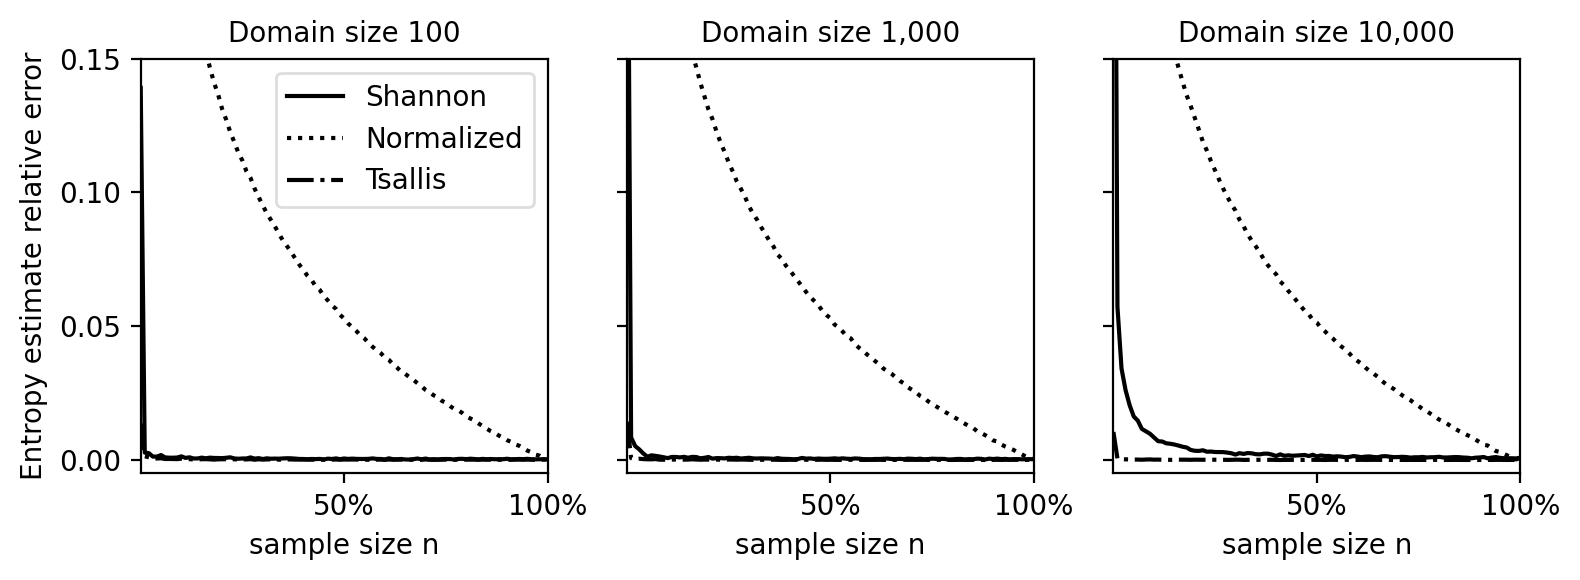

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(8, 3), sharey=True, sharex=True, dpi=200)
for i, (D, df) in enumerate(data_3_df_dict2.items()):
  if i==3: break
  ax = axes[i]
  ax.set_title('Domain size %s'%f'{D:,}', fontdict={'fontsize':10})
  ax.set_xlabel('sample size n')
  ax.set_xticks([N/2, N], ['50%', '100%'])
  ax.set_xlim(0, N)
  lns = ax.plot(df.index, df['Shannon'], entropy_lines['Shannon'], label=entropy_labels['Shannon'], color=entropy_colors['Shannon'])
  lns += ax.plot(df.index, df['Norm Shannon'], entropy_lines['Norm Shannon'], label=entropy_labels['Norm Shannon'], color=entropy_colors['Norm Shannon'])
  lns += ax.plot(df.index, df['Tsallis'], entropy_lines['Tsallis'], label=entropy_labels['Tsallis'], color=entropy_colors['Tsallis'])
  if i == 0:
    _ = ax.legend(lns, [l.get_label() for l in lns], loc='upper right', facecolor='white', framealpha=0.65)
    ax.set_ylabel('Entropy estimate relative error')
    ax.set_ylim(-0.005, 0.15)
    ax.set_yticks([0, 0.05, 0.1, 0.15])
plt.tight_layout()